In [2]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys 

import analysis_utils
from analysis_utils import get_encoder_representations, get_cosine_similarity_matrix, get_encoder_attention_plot
sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 20

In [3]:
# load checkpoints
copy_unstruct = CheckPoint.from_pt("../models/batching_strategies/MLC_batchunstruct_dallstudy1copy_nep20.pt")
unstruct = CheckPoint.from_pt("../models/batching_strategies/MLC_batchunstruct_dallstudy1_nep20.pt")

In [4]:
# load models and dataset
model_copy = copy_unstruct.load_model()
model_unstruct = unstruct.load_model()
val = unstruct.load_dataloaders(data_dir=f"../{unstruct.train_config.dir_data}", batch_size=BATCH_SIZE, use_datasets=["val"])[0]
batch= next(iter(val))

Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.7212
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 114,560
	best val loss achieved: 1.0794
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


NotImplementedError: unstructured is an unknown value for the argument batching_method.

### Attention Matrices per Layer

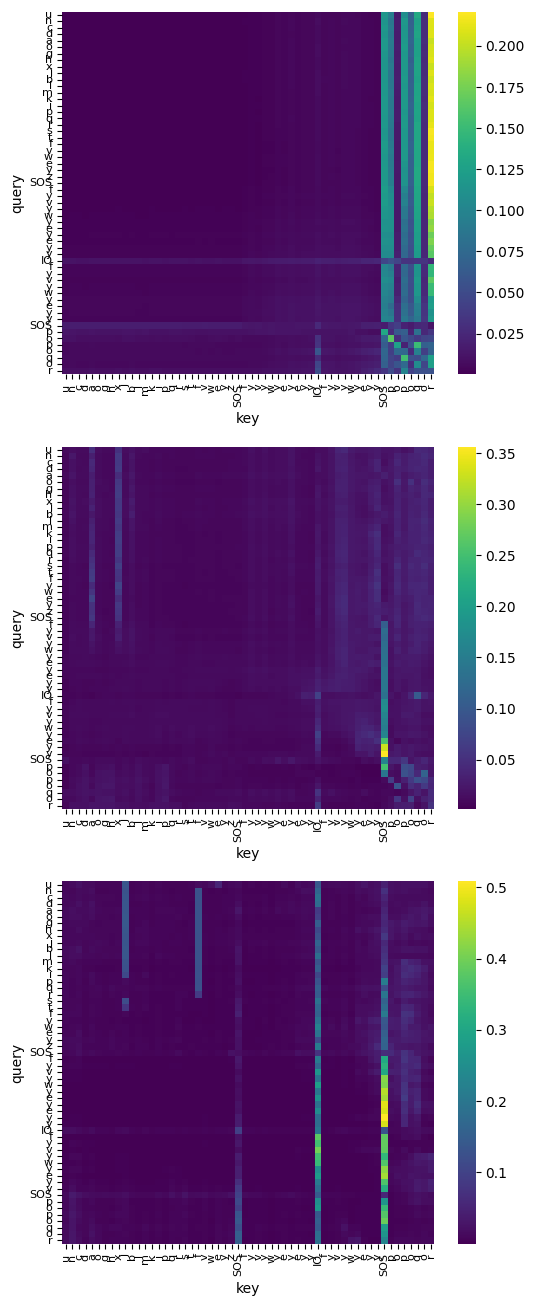

In [ ]:
fig_noncopy = get_encoder_attention_plot(model_unstruct, batch, idx=12, titles=False)

In [ ]:
#fig_noncopy.savefig("../presentations/images/noncopy_encoder_attention.svg", format="svg")

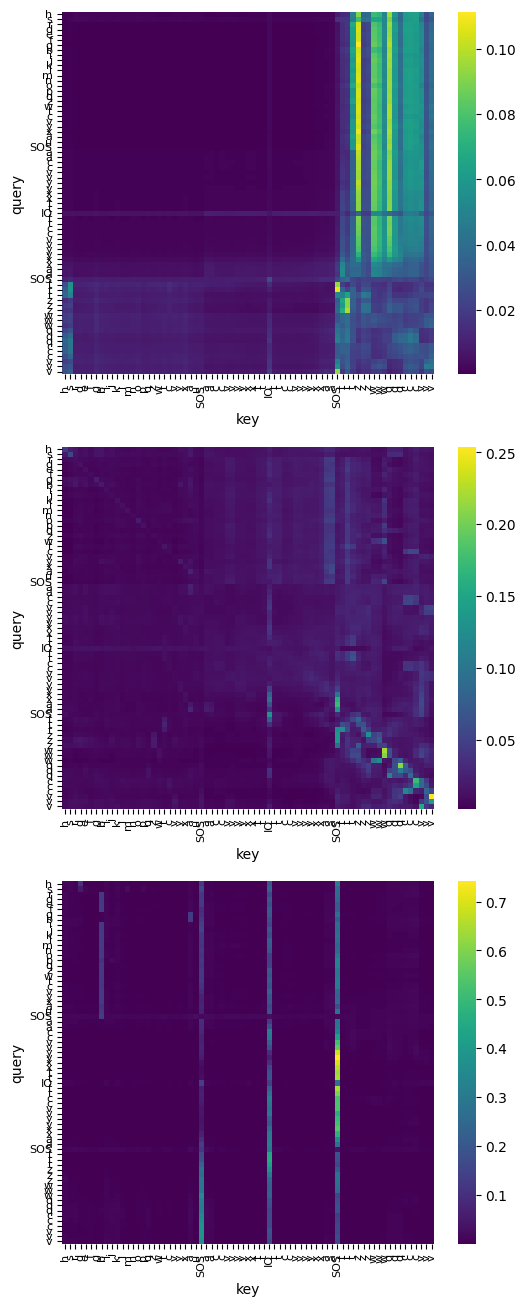

In [ ]:
fig_copy = analysis_utils.get_encoder_attention_plot(model_copy, batch, idx=9, titles=False)

In [ ]:
# fig_copy.savefig("../presentations/images/copy_encoder_attention.svg", format="svg")

### Final Encoder Representations

In [ ]:
model = copy_unstruct.load_model()
model.eval()

Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.7212
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


MLC(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
          

In [ ]:
D_val = LetterStringDataset(
    mode="val", 
    data_dir="../data/all_transformations_study1_copy_perm20", 
    batch_size=BATCH_SIZE,
    batching_method="transformation",
)
val = DataLoader(D_val, batch_sampler=D_val.sampler, collate_fn=D_val.collate_fn)

In [ ]:
D_val.set_filter("transformation", ["pred"])
pred_batch = next(iter(val))
print(pred_batch["transformation"])

['pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred']


In [ ]:
D_val.set_filter("transformation", ["succ"])
succ_batch = next(iter(val))
print(succ_batch["transformation"])

['succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ']


In [ ]:
enc_repr_pred = get_encoder_representations(pred_batch, model)
enc_repr_succ = get_encoder_representations(succ_batch, model)
D_val.set_filter("transformation", ["sort"])
sort_batch = next(iter(val))

enc_repr_sort = get_encoder_representations(sort_batch, model)

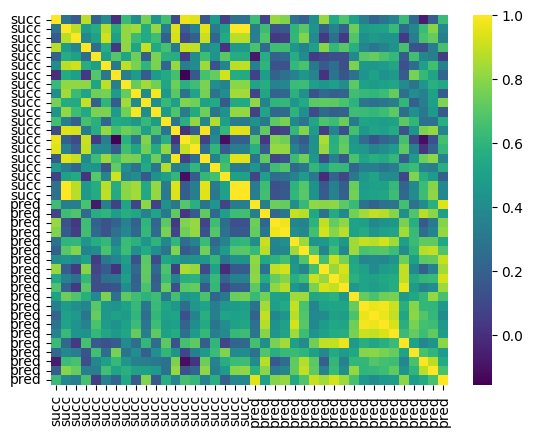

In [ ]:
cosine_sim_matrix_succpred = get_cosine_similarity_matrix([enc_repr_pred, enc_repr_succ])

labels = succ_batch["transformation"] + pred_batch["transformation"]
_ = sns.heatmap(
    cosine_sim_matrix_succpred.detach().numpy(), 
    cmap="viridis", 
    xticklabels=labels, 
    yticklabels=labels
)

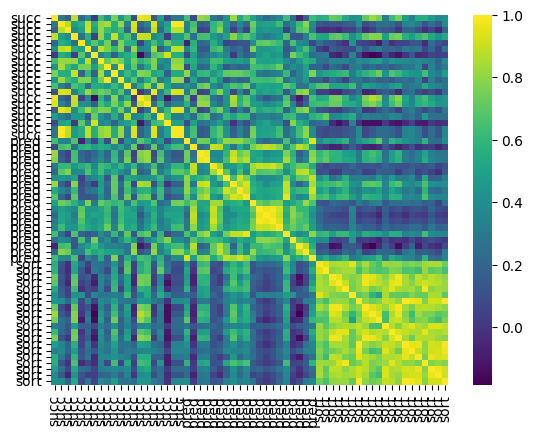

In [ ]:
cosine_sim_matrix = get_cosine_similarity_matrix([enc_repr_pred, enc_repr_succ, enc_repr_sort])

labels = succ_batch["transformation"] + pred_batch["transformation"] + sort_batch["transformation"]
_ = sns.heatmap(
    cosine_sim_matrix.detach().numpy(), 
    cmap="viridis", 
    xticklabels=labels, 
    yticklabels=labels
)

In [ ]:
D_val.transformation_types

['extend_extend_succ',
 'rr_interleave',
 'pred',
 'extend_group',
 'rr_succ',
 'sort',
 'fix_alphabetic_seq',
 'extend_pred',
 'extend_sequence',
 'rr_sort',
 'succ',
 'fix_interleave',
 'fix_extend',
 'shift',
 'replicate',
 'reverse',
 'fix_pred_succ',
 'sort_group',
 'remove_redundant']

In [6]:
def plot_full_cos_sim_matrix(model, val, batch_size):
    # order transformations to organize them in clusters:
    transformations = [
        "extend_sequence",
        "extend_pred", 
        "extend_extend_succ",
        "fix_extend", 
        "fix_alphabetic_seq",
        "fix_pred_succ",
        "pred",
        "succ",
        "shift",
        "rr_succ",
        "remove_redundant",
        "rr_sort",
        "sort",
        "reverse",
        "replicate",
        "extend_group", 
        "sort_group",
        "fix_interleave",
        "rr_interleave"
    ]

    # get encoder representations for all transformations:
    all_reprs = []
    for trans in transformations:
        val.dataset.set_filter("transformation", [trans])
        trans_batch = next(iter(val))
        trans_reprs = get_encoder_representations(trans_batch, model)
        all_reprs.append(trans_reprs)

    # construct similarity matrix
    all_cos_sim = get_cosine_similarity_matrix(all_reprs)

    # get tick labels for each transformation
    labels = []
    for trans in transformations:
        trans_labels = [""] * batch_size
        trans_labels[batch_size//2] = trans
        labels += trans_labels

    fig = plt.figure(figsize=(10,8))
    ax = sns.heatmap(
        all_cos_sim.detach().numpy(), 
        cmap="viridis",
        xticklabels=labels,
        yticklabels=labels
    )
    ax.tick_params(axis='both', length=0)  # Hide tick marks but keep labels
    return fig

#_ = plot_full_cos_sim_matrix(model, val, BATCH_SIZE)

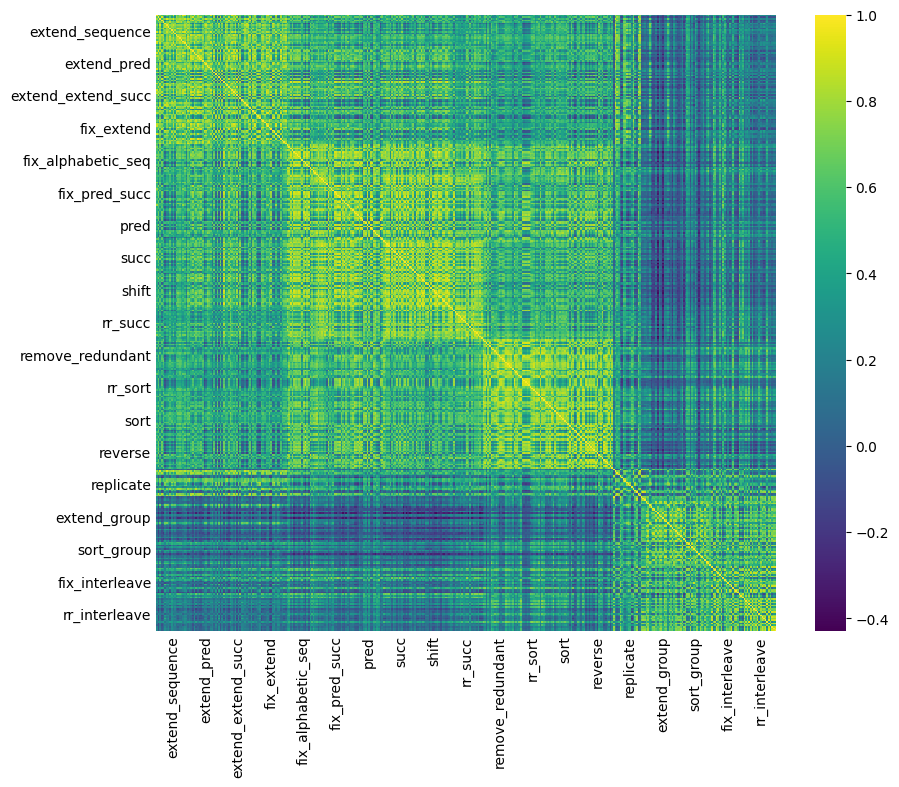

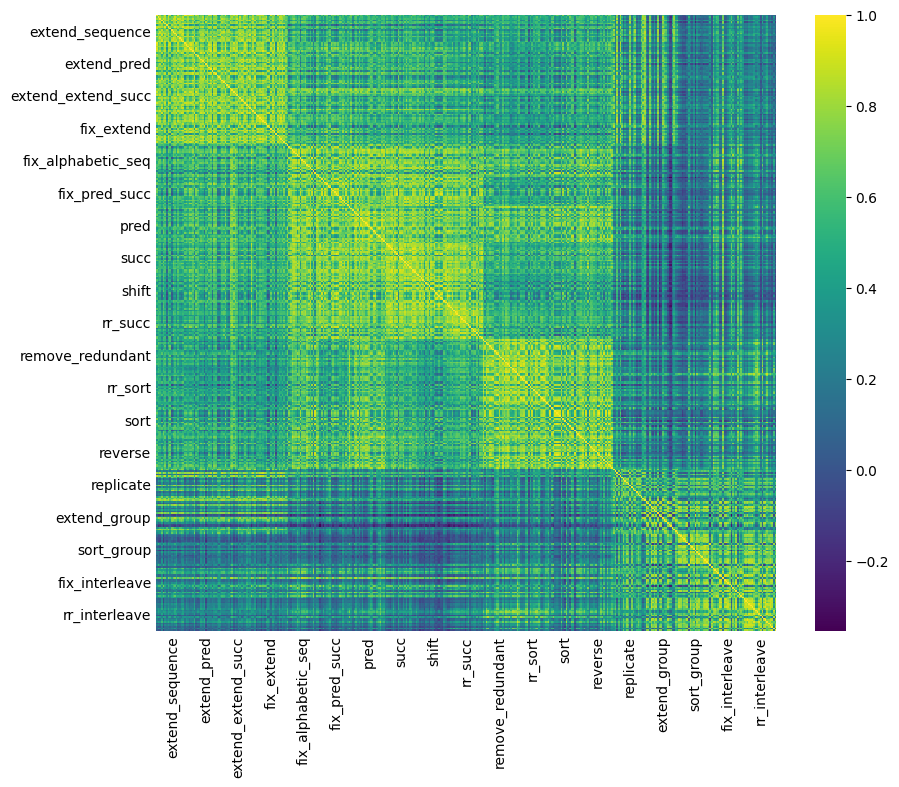

In [8]:
cp_perm_200 = CheckPoint.from_pt("../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")
model_perm_200 = cp_perm_200.load_model(verbose=False)
test_trained_alphabets = cp_perm_200.load_dataloaders(
    data_dir=f"../{cp_perm_200.train_config.dir_data}", 
    batch_size=BATCH_SIZE, 
    use_datasets=["test"],
    verbose=False)[0]
_ = plot_full_cos_sim_matrix(model_perm_200, test_trained_alphabets, BATCH_SIZE)

D_test_new = LetterStringDataset(
    "test", 
    "../data/all_transformations_study1_new_alphabets",
    batch_size=BATCH_SIZE,
    batching_method=cp_perm_200.train_config.batching_method
)
test_new_alphabets = DataLoader(D_test_new, batch_sampler=D_test_new.sampler, collate_fn=D_test_new.collate_fn)

_ = plot_full_cos_sim_matrix(model_perm_200, test_new_alphabets, BATCH_SIZE)


### 2D Representation visualizations

In [26]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [27]:
D_val_unstruct = LetterStringDataset(
    mode="val", 
    data_dir=f"../{unstruct.train_config.dir_data}", 
    batch_size=22912
)
val_un = DataLoader(D_val_unstruct, batch_sampler=D_val_unstruct.sampler, collate_fn=D_val_unstruct.collate_fn)

In [28]:
all_data = next(iter(val_un))

In [ ]:
representations = get_encoder_representations(all_data, model)

In [ ]:
all_repr = representations.detach().numpy()

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_repr)

In [ ]:
tsne = TSNE(n_components=2, verbose=1, perplexity=40)
tsne_results = tsne.fit_transform(all_repr)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 22912 samples in 0.011s...
[t-SNE] Computed neighbors for 22912 samples in 21.431s...
[t-SNE] Computed conditional probabilities for sample 1000 / 22912
[t-SNE] Computed conditional probabilities for sample 2000 / 22912
[t-SNE] Computed conditional probabilities for sample 3000 / 22912
[t-SNE] Computed conditional probabilities for sample 4000 / 22912
[t-SNE] Computed conditional probabilities for sample 5000 / 22912
[t-SNE] Computed conditional probabilities for sample 6000 / 22912
[t-SNE] Computed conditional probabilities for sample 7000 / 22912
[t-SNE] Computed conditional probabilities for sample 8000 / 22912
[t-SNE] Computed conditional probabilities for sample 9000 / 22912
[t-SNE] Computed conditional probabilities for sample 10000 / 22912
[t-SNE] Computed conditional probabilities for sample 11000 / 22912
[t-SNE] Computed conditional probabilities for sample 12000 / 22912
[t-SNE] Computed conditional probabilities for s

In [ ]:
repr_df = pd.DataFrame({"transformation": all_data["transformation"], "alphabet": all_data["alphabet"]})
repr_df["PCA1"] = pca_result[:,0]
repr_df["PCA2"] = pca_result[:,1]
repr_df['tSNE1'] = tsne_results[:,0]
repr_df['tSNE2'] = tsne_results[:,1]

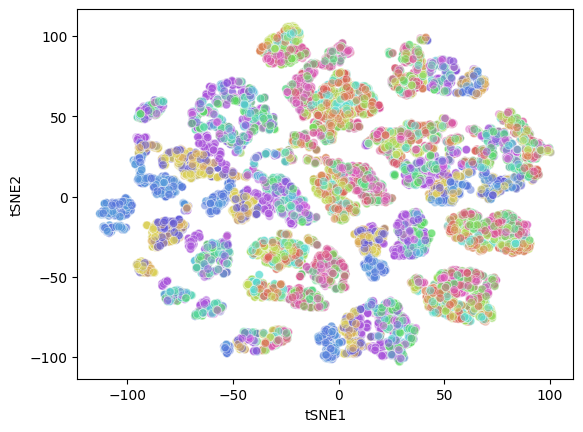

In [ ]:
_ = sns.scatterplot(
    data=repr_df,
    x="tSNE1", y="tSNE2",
    hue="alphabet",
    palette=sns.color_palette("hls", len(repr_df.alphabet.unique())),
    alpha=0.5,
    legend=None
)
#_ = plt.legend(title="transformation type", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

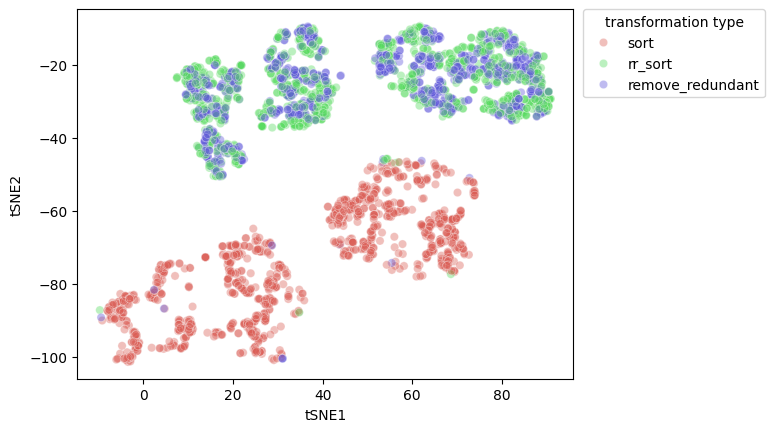

In [ ]:
_ = sns.scatterplot(
    data=repr_df[repr_df["transformation"].isin(["remove_redundant","rr_sort","sort"])],
    x="tSNE1", y="tSNE2",
    hue="transformation",
    palette=sns.color_palette("hls", 3),
    legend="full",
    alpha=0.4
)
_ = plt.legend(title="transformation type", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)


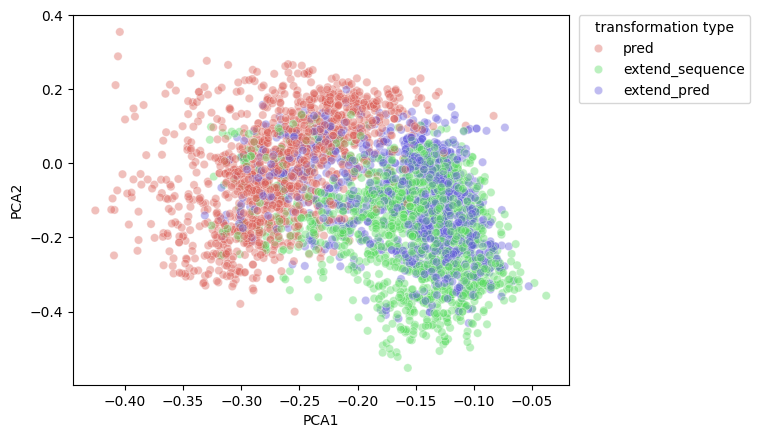

In [ ]:
_ = sns.scatterplot(
    data=repr_df[repr_df["transformation"].isin(["extend_sequence","pred","extend_pred"])],
    x="PCA1", y="PCA2",
    hue="transformation",
    palette=sns.color_palette("hls", 3),
    legend="full",
    alpha=0.4
)
_ = plt.legend(title="transformation type", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)